![tasks](../docs/tasks.png)


## データエンジニアリング

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

In [2]:
# load時間を考えて、0~2のファイルを読み込むこととした。
df = pd.DataFrame()
for i in range(3):
    df_unprocessed  = pd.read_csv(f'../data/unprocessed-data/valve1_{i}.csv',sep=';')
    df_unprocessed = df_unprocessed.sort_values(by='datetime', inplace=False)
    df = pd.concat([df, df_unprocessed])
df = df.reset_index(drop=True)

In [3]:
df.head(3)

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
0,2020-03-09 10:14:33,0.026588,0.040111,1.33020,0.054711,79.3366,26.0199,233.062,32.0,0.0,0.0
1,2020-03-09 10:14:34,0.026170,0.040453,1.35399,0.382638,79.5158,26.0258,236.040,32.0,0.0,0.0
2,2020-03-09 10:14:35,0.026199,0.039419,1.54006,0.710565,79.3756,26.0265,251.380,32.0,0.0,0.0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Accelerometer1RMS,3367.0,0.026755,0.000371,0.025553,0.026506,0.026760,0.027019,0.027946
Accelerometer2RMS,3367.0,0.040155,0.000904,0.037474,0.039537,0.040147,0.040734,0.053439
Current,3367.0,0.985841,0.274451,0.375488,0.750555,1.011110,1.210285,1.662610
Pressure,3367.0,0.081592,0.249812,-0.929070,0.054711,0.054711,0.382638,1.038490
Temperature,3367.0,74.330020,2.765793,69.243100,72.100000,73.950700,75.864000,79.889100
Thermocouple,3367.0,25.755188,0.178642,25.457200,25.609500,25.750400,25.885400,26.104400
Voltage,3367.0,231.091404,10.650518,203.725000,225.411500,231.259000,236.951500,255.324000
Volume Flow RateRMS,3367.0,31.765678,0.640155,30.000000,31.002700,32.000000,32.000000,33.000000
anomaly,3367.0,0.338580,0.473297,0.000000,0.000000,0.000000,1.000000,1.000000
changepoint,3367.0,0.003267,0.057073,0.000000,0.000000,0.000000,0.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3367 entries, 0 to 3366
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             3367 non-null   object 
 1   Accelerometer1RMS    3367 non-null   float64
 2   Accelerometer2RMS    3367 non-null   float64
 3   Current              3367 non-null   float64
 4   Pressure             3367 non-null   float64
 5   Temperature          3367 non-null   float64
 6   Thermocouple         3367 non-null   float64
 7   Voltage              3367 non-null   float64
 8   Volume Flow RateRMS  3367 non-null   float64
 9   anomaly              3367 non-null   float64
 10  changepoint          3367 non-null   float64
dtypes: float64(10), object(1)
memory usage: 289.5+ KB


In [6]:
print(df.groupby('anomaly').size())

anomaly
0.0    2227
1.0    1140
dtype: int64


In [7]:
df = df.drop(["datetime", "changepoint"], axis=1)
df.head(3)

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
0,0.026588,0.040111,1.33020,0.054711,79.3366,26.0199,233.062,32.0,0.0
1,0.026170,0.040453,1.35399,0.382638,79.5158,26.0258,236.040,32.0,0.0
2,0.026199,0.039419,1.54006,0.710565,79.3756,26.0265,251.380,32.0,0.0


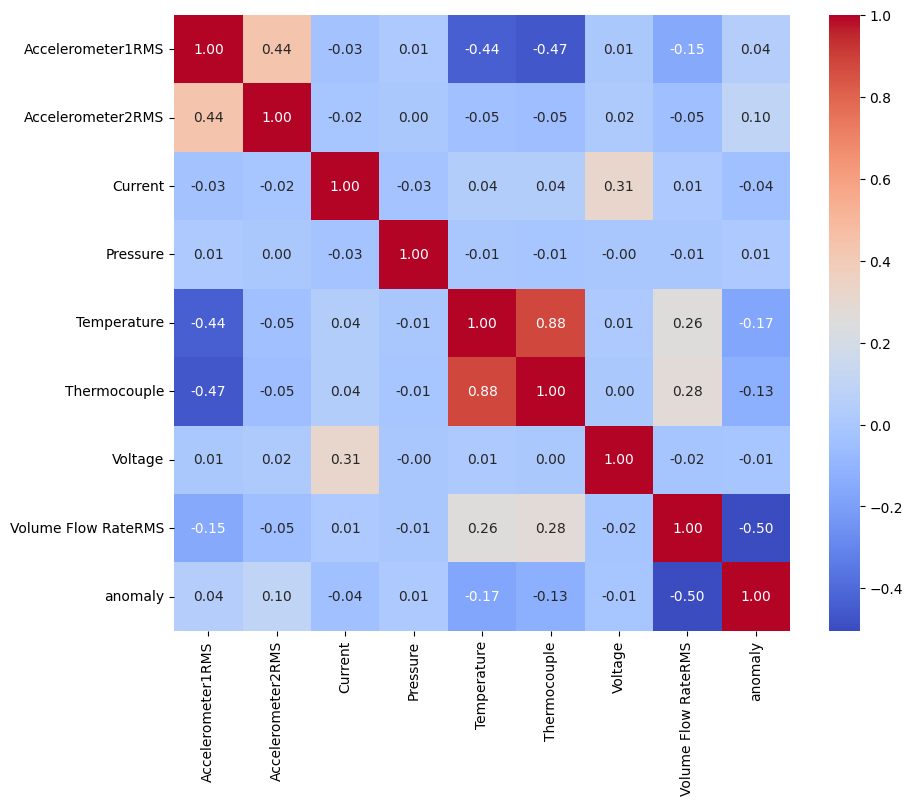

In [12]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.show()


In [9]:
df_x = df.drop('anomaly', axis=1)
#目的変数
df_y = df.anomaly

In [10]:
df_x_train, df_x_test, df_y_train, df_y_test = train_test_split(df_x, df_y, test_size=0.3, random_state=42, stratify=df_y)

In [11]:
for name, item in {
    'df_x_train': df_x_train,
    'df_x_test': df_x_test,
    'df_y_train': df_y_train,
    'df_y_test': df_y_test
}.items():
    item.to_csv(f'../data/treated-data/{name}.csv', index=False)